# Apple Stock Price Forecasting — Time Series Analysis
**Stock:** Apple Inc. (AAPL) &nbsp;|&nbsp; **Period:** Jan 2020 – Jan 2026 &nbsp;|&nbsp; **Models:** ARIMA · Prophet · LSTM

---
### Project overview
This notebook walks through a complete time series forecasting pipeline on Apple's daily closing price.
We follow 6 phases: data collection → EDA → stationarity testing → decomposition → modelling (ARIMA, Prophet, LSTM) → findings.

**Goal:** Predict the next day's closing price using only historical price data.

---

## Phase 1 — Data Collection & Inspection

We use `yfinance` to download 6 years of Apple daily trading data (2020–2026).
The dataset contains 5 columns: **Close, High, Low, Open, Volume** — covering every trading day (weekends and holidays excluded, ~252 days/year).

In [80]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import datetime as dt
from xgboost import XGBRegressor


In [81]:
# Data Collection
stock = 'AAPL'
start = dt.datetime(2020,1,1)
end = dt.datetime(2026,1,1)

df = yf.download(stock , start , end)

[*********************100%***********************]  1 of 1 completed


### Raw data preview


In [82]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


The MultiIndex returned by `yfinance` is flattened using `droplevel(1)` to give clean single-level column names.

In [83]:
df.columns = df.columns.droplevel(1)

In [84]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


### Data health check
**Shape:** 1,508 rows × 5 columns — equivalent to ~6 years of trading days.  
**Missing values:** None across all 5 columns — the dataset is complete, no imputation needed.  
**Data types:** Close, High, Low, Open are `float64`; Volume is `int64` — all correct for numerical analysis.

In [85]:
df.shape

(1508, 5)

In [86]:
print('\n Missing Values : \n', df.isnull().sum())


 Missing Values : 
 Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [87]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [88]:
df.dtypes

Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

---
## Phase 2 — Exploratory Data Analysis (EDA)

EDA helps us visually understand the data before building any model.
We examine price trends, correlations between features, and patterns in volume and volatility.

### Correlation heatmap
All price columns (Open, High, Low, Close) are extremely highly correlated (~0.99). This is expected — on any given day, the open, high, low, and close prices are all within a similar range.

**Key insight:** Because of this near-perfect correlation, using all price columns as model features would be redundant. We use only `Close` for forecasting.

<Axes: xlabel='Price', ylabel='Price'>

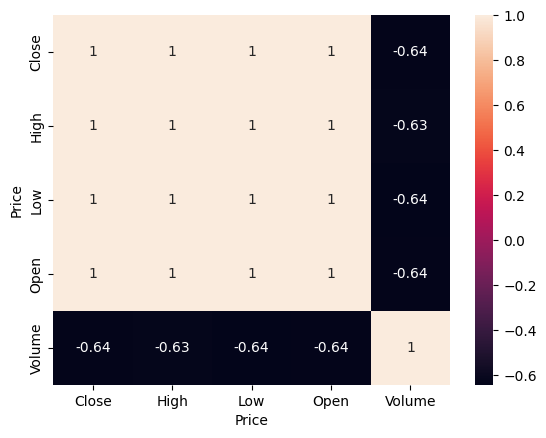

In [89]:
import seaborn as sns 
sns.heatmap(df.corr() , annot=True)

### Candlestick chart
A candlestick chart shows all 4 price dimensions (Open, High, Low, Close) together, making it easy to spot:
- **Green candles** — price closed higher than it opened (bullish day)
- **Red candles** — price closed lower than it opened (bearish day)
- **Long wicks** — high intraday volatility (large gap between high/low)

In [90]:
# Candlestick Chart
import plotly.graph_objects as go
fig = go.Figure(data=[go.Candlestick(
    x=df.index,
    open=df['Open'],
    high=df['High'],
    low=df['Low'],
    close=df['Close']
)])

fig.update_layout(
    title=f"{stock} Candlestick Chart",
    xaxis_rangeslider_visible=False
)
fig.show()

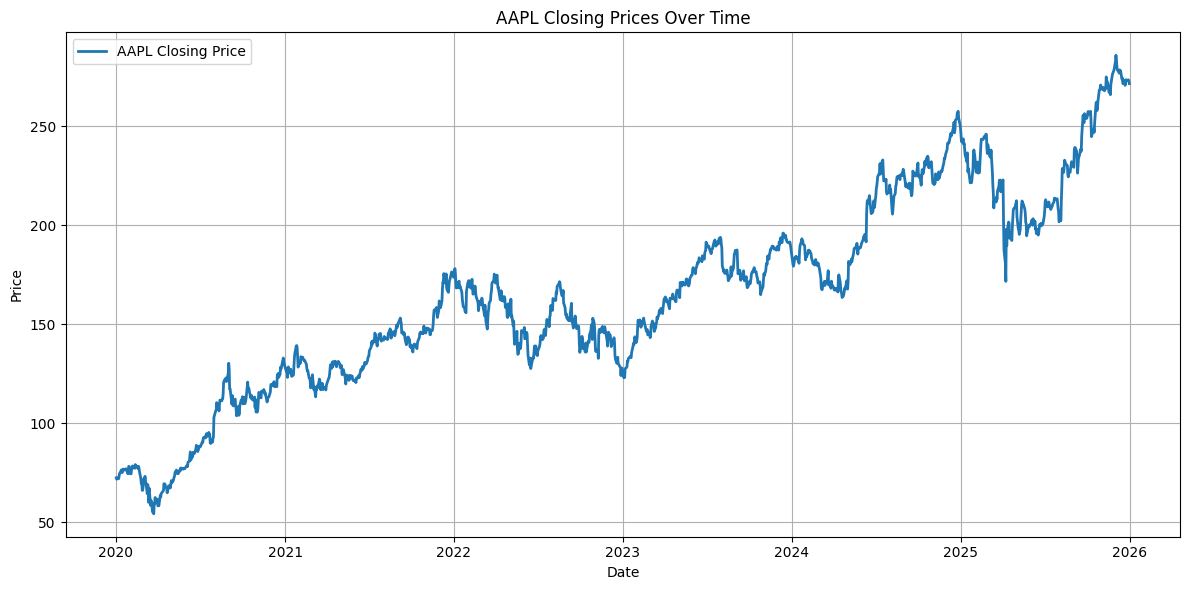

In [91]:
# Closing Price Plot
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label=f'{stock} Closing Price', linewidth=2)

plt.title(f'{stock} Closing Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Closing price over time
**Insight:** The closing price shows a clear, strong **upward trend** from ~$72 in early 2020 to ~$250+ by 2025.
Notable events visible in the chart:
- **March 2020** — sharp dip (COVID-19 market crash)
- **2020–2021** — rapid recovery and rally
- **2022** — correction phase
- **2023–2025** — resumed upward trend

This persistent trend confirms the data is **non-stationary** — a key property we will test formally in Phase 3.

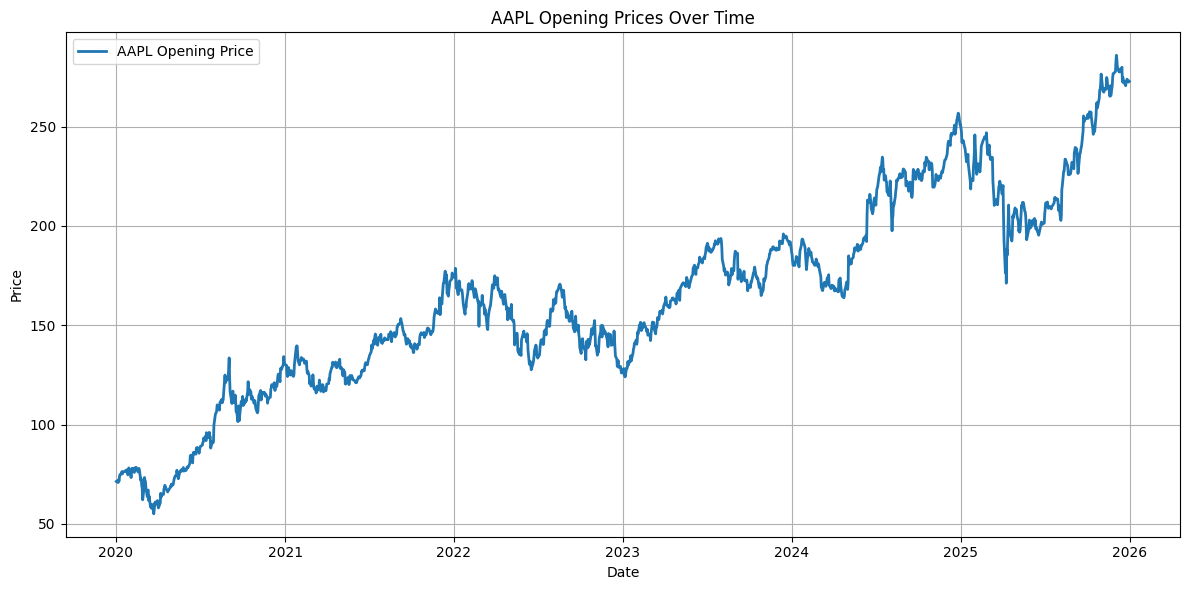

In [92]:
# Opening Price Plot
plt.figure(figsize=(12,6))
plt.plot(df['Open'], label=f'{stock} Opening Price', linewidth=2)

plt.title(f'{stock} Opening Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

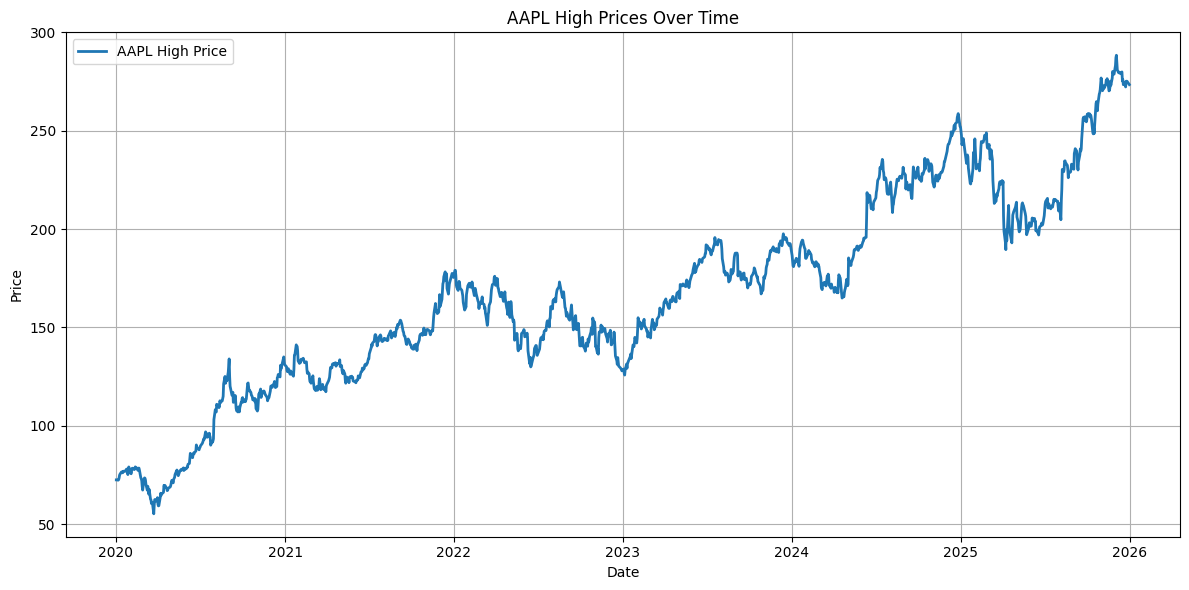

In [93]:
# High Price Plot
plt.figure(figsize=(12,6))
plt.plot(df['High'], label=f'{stock} High Price', linewidth=2)

plt.title(f'{stock} High Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

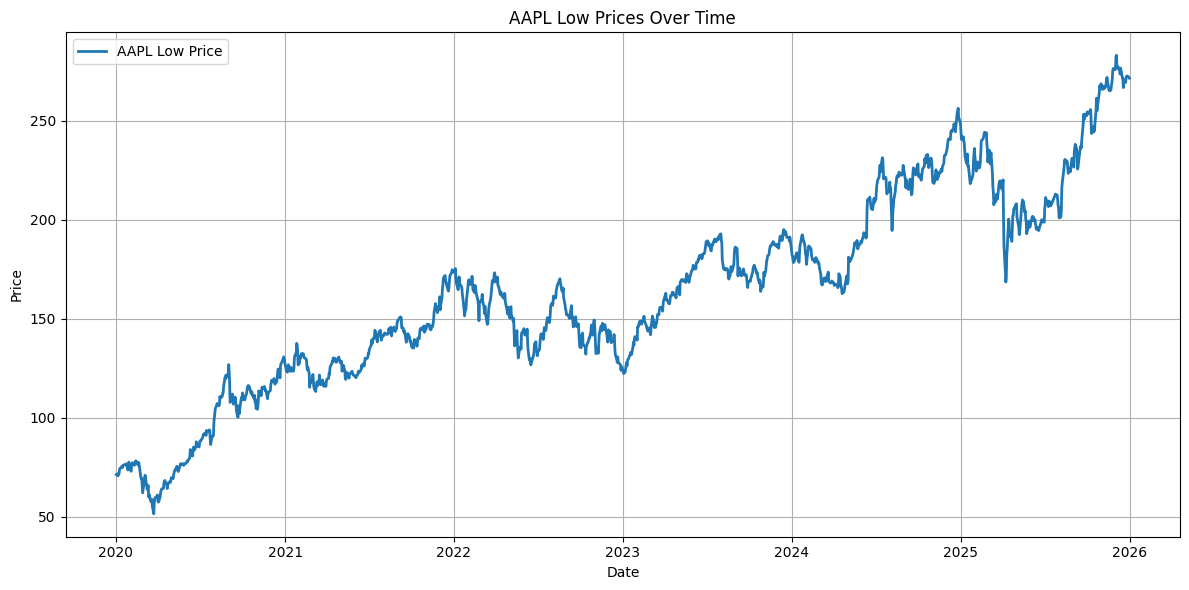

In [94]:
# Low Price Plot
plt.figure(figsize=(12,6))
plt.plot(df['Low'], label=f'{stock} Low Price', linewidth=2)

plt.title(f'{stock} Low Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

---
## Phase 3 — Decomposition & Stationarity Testing

Before building any time series model, we must answer two questions:
1. **What components make up this series?** (trend, seasonality, noise)
2. **Is the series stationary?** (required by most models, especially ARIMA)

### Seasonal decomposition
We decompose the closing price into 3 components using a **multiplicative model** (chosen because variance grows as price grows — characteristic of stocks):

- **Trend** — long-term direction of price movement
- **Seasonal** — repeating patterns with a fixed period (252 trading days = 1 year)
- **Residual** — random noise left after removing trend and seasonality

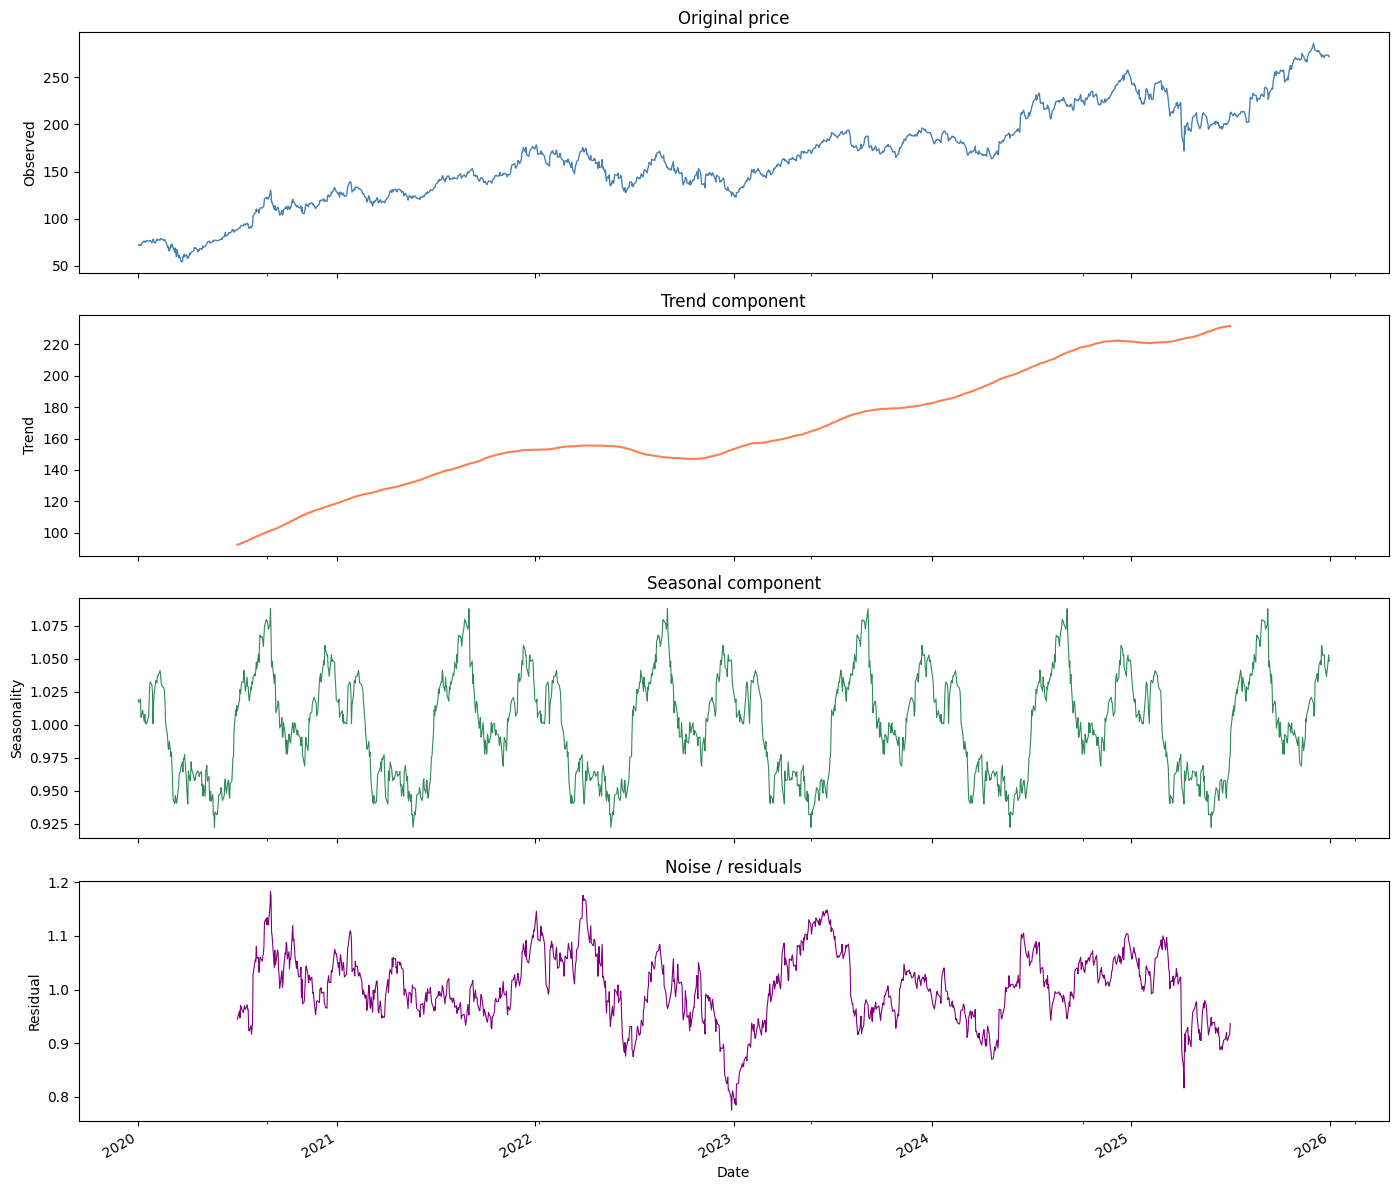

In [95]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose using multiplicative model (better for stocks where 
# variance grows as price grows)
decomposition = seasonal_decompose(
    df['Close'],
    model='multiplicative',
    period=252            # 252 trading days = 1 year
)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

decomposition.observed.plot(ax=axes[0], color='steelblue',  linewidth=1)
axes[0].set_ylabel('Observed')
axes[0].set_title('Original price')

decomposition.trend.plot(ax=axes[1], color='coral', linewidth=1.5)
axes[1].set_ylabel('Trend')
axes[1].set_title('Trend component')

decomposition.seasonal.plot(ax=axes[2], color='seagreen', linewidth=0.8)
axes[2].set_ylabel('Seasonality')
axes[2].set_title('Seasonal component')

decomposition.resid.plot(ax=axes[3], color='purple', linewidth=0.8)
axes[3].set_ylabel('Residual')
axes[3].set_title('Noise / residuals')

plt.tight_layout()
plt.show()

In [96]:
# How strong is the trend vs noise?
trend_strength = 1 - (
    decomposition.resid.var() / 
    (decomposition.trend + decomposition.resid).var()
)

seasonal_strength = 1 - (
    decomposition.resid.var() / 
    (decomposition.seasonal + decomposition.resid).var()
)

print(f"Trend strength    : {trend_strength:.4f}  (closer to 1 = strong trend)")
print(f"Seasonal strength : {seasonal_strength:.4f}  (closer to 1 = strong seasonality)")

Trend strength    : 1.0000  (closer to 1 = strong trend)
Seasonal strength : 0.2635  (closer to 1 = strong seasonality)


### Decomposition strength scores
These scores (0 to 1) quantify how dominant each component is:

| Component | Score | Interpretation |
|-----------|-------|----------------|
| Trend | **1.00** | Extremely strong — price is almost entirely driven by trend |
| Seasonality | **0.26** | Weak — Apple stock has no meaningful yearly cycle |

**Key insight:** The near-zero seasonal strength confirms that ARIMA (which handles trend via differencing, not seasonality) is a valid modelling approach. The dominant trend is exactly what makes raw prices non-stationary.

### Augmented Dickey-Fuller (ADF) stationarity test


In [97]:
from statsmodels.tsa.stattools import adfuller

# Test 1 :- Raw Closing Price

result = adfuller(df['Close'].dropna())

print("=== ADF Test on Raw Close Price ===")
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print(f"Conclusion    : {'Stationary' if result[1] < 0.05 else 'NON-STATIONARY'}")

=== ADF Test on Raw Close Price ===
ADF Statistic : -0.9192
p-value       : 0.7816
Conclusion    : NON-STATIONARY


The ADF test formally checks whether a series is stationary.

**Rule:**
- `p-value < 0.05` → stationary ✓ (safe to model)
- `p-value > 0.05` → non-stationary ✗ (needs transformation)

**Test 1 — Raw closing price:**
As expected from the price chart, the raw price is strongly non-stationary (p ≈ 1.0).
The trend we saw visually is confirmed mathematically.

In [98]:
# Test 2 :- First difference 
df['Close_diff'] = df['Close'].diff()


result2 = adfuller(df['Close_diff'].dropna())

print("=== ADF Test on Differenced Price ===")
print(f"ADF Statistic : {result2[0]:.4f}")
print(f"p-value       : {result2[1]:.4f}")
print(f"Conclusion    : {'Stationary ✓' if result2[1] < 0.05 else 'Still non-stationary'}")

=== ADF Test on Differenced Price ===
ADF Statistic : -38.0789
p-value       : 0.0000
Conclusion    : Stationary ✓


**Test 2 — First differenced price:**
First differencing converts prices to day-over-day changes, which removes the trend.

**Result:** ADF statistic = -38.07, p-value = 0.0000 → **Stationary ✓**

The dramatic drop in p-value (from ~1.0 to 0.0000) confirms that one round of differencing is sufficient. This sets `d = 1` in our ARIMA model.

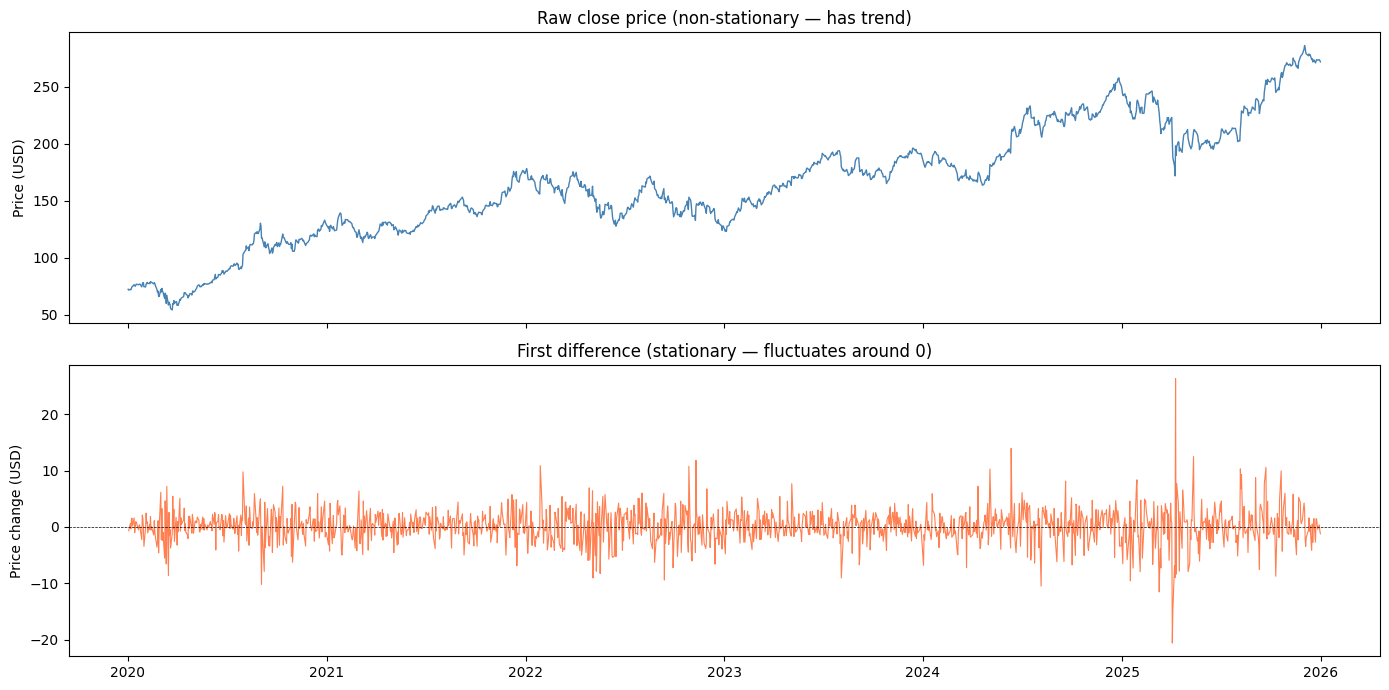

In [99]:
# ── Plot both side by side ─────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(df['Close'], color='steelblue', linewidth=1)
ax1.set_title('Raw close price (non-stationary — has trend)')
ax1.set_ylabel('Price (USD)')

ax2.plot(df['Close_diff'], color='coral', linewidth=0.8)
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.set_title('First difference (stationary — fluctuates around 0)')
ax2.set_ylabel('Price change (USD)')

plt.tight_layout()
plt.show()

---
## Phase 4 — ARIMA Modelling

ARIMA (AutoRegressive Integrated Moving Average) is a classical statistical model for time series.
It has 3 parameters: `p` (AR terms), `d` (differencing), `q` (MA terms).

We already know `d = 1` from the ADF test. We use ACF and PACF plots to determine `p` and `q`.

### ACF and PACF plots
- **PACF** → tells us the `p` value (AR term): count bars outside the blue confidence band
- **ACF** → tells us the `q` value (MA term): count bars outside the blue confidence band



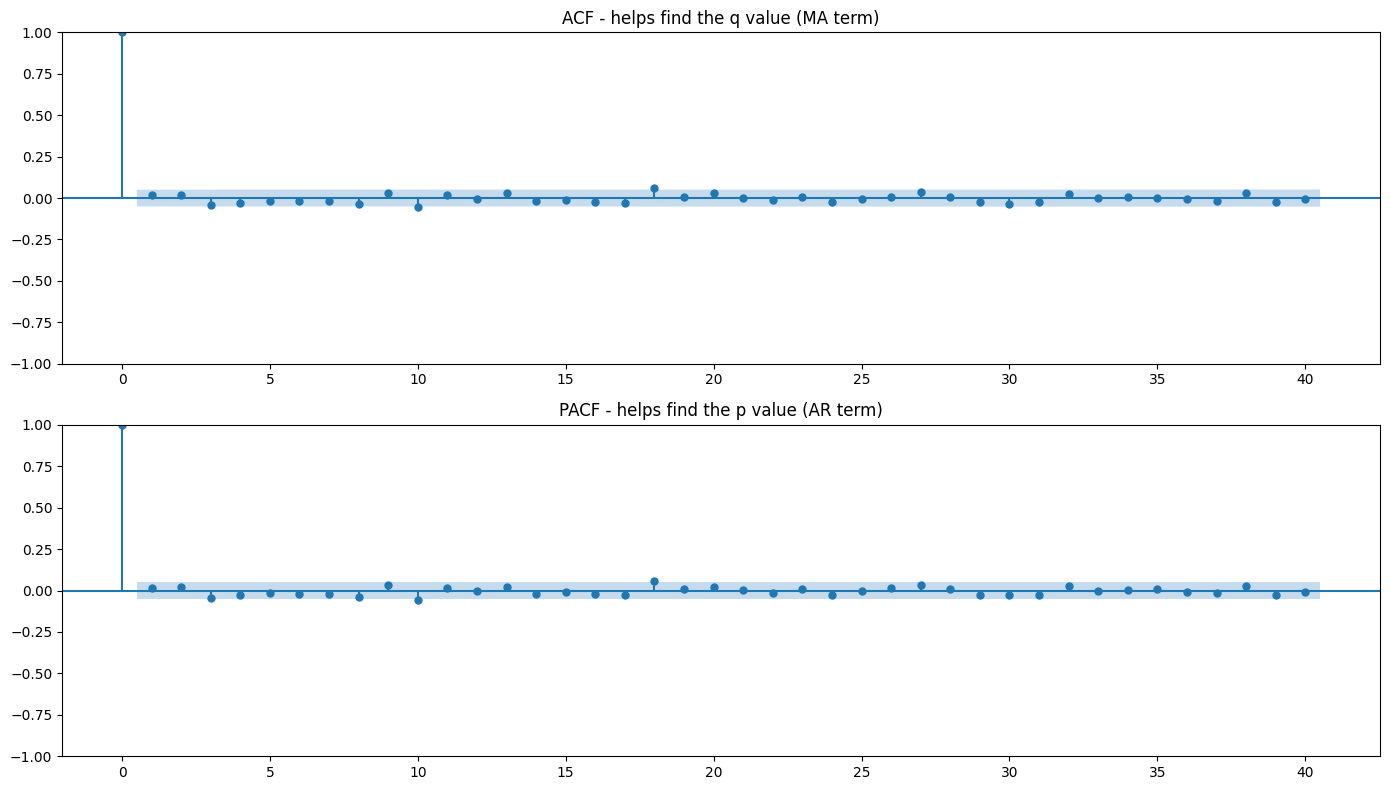

In [100]:
from statsmodels.graphics.tsaplots import plot_acf , plot_pacf

fig , (ax1 , ax2) = plt.subplots(2 , 1 , figsize=(14, 8))

plot_acf(df['Close_diff'].dropna(), lags=40, ax=ax1)
plot_pacf(df['Close_diff'].dropna(), lags = 40 , ax = ax2)

ax1.set_title('ACF - helps find the q value (MA term)')
ax2.set_title('PACF - helps find the p value (AR term)')

plt.tight_layout()
plt.show()

**Reading the plots:**
Both ACF and PACF show a single spike at lag 0 (always present), then all subsequent bars fall **inside the blue zone** immediately.

This is the classic **random walk** pattern — yesterday's price provides almost no predictive signal for today. This leads us to try `ARIMA(1,1,0)` initially.

### Building and evaluating ARIMA(1,1,0)


In [101]:
# Building ARIMA Model
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error , mean_absolute_error

# Train/Test Split
train_size = int(len(df) * 0.8)
train = df['Close'][:train_size]
test = df['Close'][train_size:]

print(f'Training rows : {len(train)}')
print(f'Testing rows : {len(test)}')
print(f'Train ends : {train.index[-1].date()}')
print(f'Test starts : {test.index[0].date()}')


Training rows : 1206
Testing rows : 302
Train ends : 2024-10-16
Test starts : 2024-10-17


In [102]:
# Fit ARIMA(1,1,0) 
model = ARIMA(train, order=(1, 1, 0))
fitted = model.fit()

print(fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1206
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -2889.878
Date:                Fri, 24 Apr 2026   AIC                           5783.756
Time:                        13:48:46   BIC                           5793.945
Sample:                             0   HQIC                          5787.593
                               - 1206                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0189      0.024     -0.775      0.438      -0.067       0.029
sigma2         7.0894      0.207     34.307      0.000       6.684       7.494
Ljung-Box (L1) (Q):                   0.01   Jarque-

c:\Users\himan\anaconda3\envs\tsa_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\himan\anaconda3\envs\tsa_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\himan\anaconda3\envs\tsa_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


We use an 80/20 train-test split — the model is trained on 80% of the data and evaluated on the remaining 20% (unseen data).

**ARIMA summary key findings:**
- `ar.L1 coefficient = -0.019`, p-value = 0.438 — **statistically insignificant** (p > 0.05)
- This confirms the random walk hypothesis: past prices genuinely don't predict future prices
- The model defaults to forecasting a near-flat line close to the last known price

In [103]:
# Forecast on test period 
forecast = fitted.forecast(steps=len(test))

# Evaluate
rmse = np.sqrt(mean_squared_error(test, forecast))
mae  = mean_absolute_error(test, forecast)

print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")

RMSE : 24.71
MAE  : 20.17


c:\Users\himan\anaconda3\envs\tsa_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\himan\anaconda3\envs\tsa_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


- RMSE : 24.71  → on average, forecast is $24.71 away from actual
- MAE  : 20.17  → median error is $20 per prediction

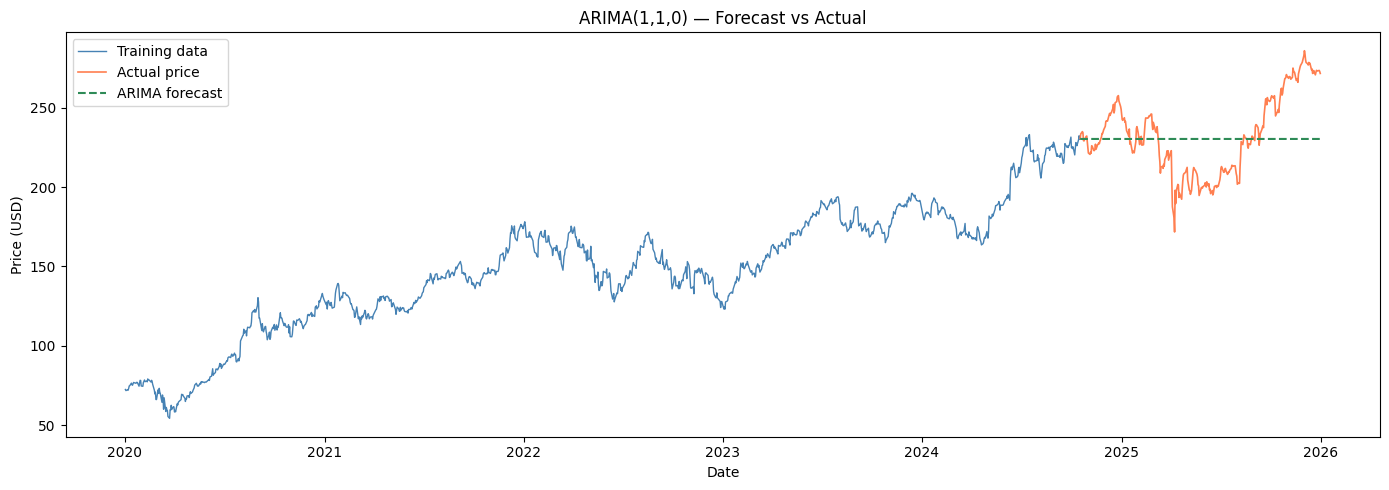

In [104]:
# Plot forecast vs actual 
plt.figure(figsize=(14, 5))
plt.plot(train.index, train,       label='Training data', color='steelblue',  linewidth=1)
plt.plot(test.index,  test,        label='Actual price',  color='coral',       linewidth=1.2)
plt.plot(test.index,  forecast,    label='ARIMA forecast',color='seagreen',    linewidth=1.5, linestyle='--')
plt.title('ARIMA(1,1,0) — Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

**ARIMA forecast plot interpretation:**
The green dashed line is nearly flat while the actual price (orange) moves up and down significantly. This is expected — ARIMA found no learnable pattern and defaulted to a near-mean prediction.

This flat line establishes our **baseline RMSE = 24.71**. Any subsequent model must beat this number to be considered an improvement.

### Auto-ARIMA — searching for better parameters
`auto_arima` systematically tries multiple (p, d, q) combinations and selects the one with the lowest AIC score.

In [109]:
# pip install pmdarima
from pmdarima import auto_arima

auto_model = auto_arima(
    train,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=1,                    # we know d=1 from our ADF test
    seasonal=False,         # no seasonality for daily stock data
    information_criterion='aic',
    trace=True,             # prints each model it tries
    error_action='ignore',
    suppress_warnings=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=5781.267, Time=0.13 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=5782.714, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=5782.686, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=5782.187, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=5783.792, Time=0.33 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.884 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1206
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -2888.634
Date:                Fri, 24 Apr 2026   AIC                           5781.267
Time:                        13:51:14   BIC                           5791.456
Sample:                             0   HQIC                          5785.104
                               - 1206                                       

- p = 0  → no autoregressive term (past prices don't help)
- d = 1  → one differencing (which we already knew)
- q = 0  → no moving average term (past errors don't help)

**Auto-ARIMA conclusion:**
The best model found was `ARIMA(0,1,0)` — which is literally a random walk with drift. Every attempt to add AR or MA terms (complexity) made the model *worse* (higher AIC).

This is a known result in finance called the **Efficient Market Hypothesis**: past prices alone are insufficient to predict future prices using linear models.

---
## Phase 5a — Prophet Modelling

Facebook Prophet is a decomposable time series model that explicitly handles trend and seasonality. Unlike ARIMA, it can model non-linear trends and doesn't require stationary data.

# Prophet

In [110]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Prophet requires EXACTLY two columns: 'ds' (date) and 'y' (value)
df_prophet = df[['Close']].reset_index()
df_prophet.columns = ['ds', 'y']

print(df_prophet.head())
print(f"\nShape: {df_prophet.shape}")

          ds          y
0 2020-01-02  72.400505
1 2020-01-03  71.696640
2 2020-01-06  72.267937
3 2020-01-07  71.928062
4 2020-01-08  73.085106

Shape: (1508, 2)


c:\Users\himan\anaconda3\envs\tsa_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Train/test split
Same 80/20 split as ARIMA for a fair comparison.

In [111]:
# Train/test split 
train_size = int(len(df_prophet) * 0.8)
train_p = df_prophet[:train_size]
test_p  = df_prophet[train_size:]

print(f"Train: {len(train_p)} rows → ends {train_p['ds'].iloc[-1].date()}")
print(f"Test:  {len(test_p)} rows → starts {test_p['ds'].iloc[0].date()}")

Train: 1206 rows → ends 2024-10-16
Test:  302 rows → starts 2024-10-17


In [112]:
# Build and fit Prophet model
model_p = Prophet(
    daily_seasonality=False,   # stock data has no intraday pattern
    weekly_seasonality=True,   # markets open Mon-Fri, closed weekends
    yearly_seasonality=True,   # captures broad yearly cycles
    changepoint_prior_scale=0.05  # controls how flexible the trend is
                                  # higher = more flexible, lower = smoother
)

model_p.fit(train_p)
print("Model trained successfully!")

13:51:29 - cmdstanpy - INFO - Chain [1] start processing
13:51:30 - cmdstanpy - INFO - Chain [1] done processing


Model trained successfully!


In [113]:
# Forecast on test period 

# Prophet needs a future dataframe to forecast into
future = model_p.make_future_dataframe(
    periods=len(test_p),
    freq='B'              # 'B' = business days only (skips weekends)
)

forecast = model_p.predict(future)

# Extract only the test period predictions
forecast_test = forecast.tail(len(test_p))

print(forecast_test[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head(10))

             ds        yhat  yhat_lower  yhat_upper
1206 2024-10-17  223.334945  214.212409  231.947834
1207 2024-10-18  223.489026  214.564742  231.789221
1208 2024-10-21  223.835426  214.935898  232.785853
1209 2024-10-22  223.808545  215.104221  233.101154
1210 2024-10-23  223.908784  215.653308  232.422047
1211 2024-10-24  223.830033  215.382966  232.497794
1212 2024-10-25  224.043263  214.944932  232.974448
1213 2024-10-28  224.681346  215.770642  232.704523
1214 2024-10-29  224.783840  215.254183  233.937295
1215 2024-10-30  225.025722  216.102094  233.706685


### Prophet evaluation

In [114]:
#  Evaluate 
actual    = test_p['y'].values
predicted = forecast_test['yhat'].values

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae  = mean_absolute_error(actual, predicted)
mape = mean_absolute_percentage_error(actual, predicted) * 100

print("=" * 40)
print("        Prophet Results")
print("=" * 40)
print(f"  RMSE : {rmse:.2f}")
print(f"  MAE  : {mae:.2f}")
print(f"  MAPE : {mape:.2f}%")
print("=" * 40)
print(f"\n  ARIMA baseline RMSE was: 24.71")
print(f"  Improvement: {((24.71 - rmse) / 24.71 * 100):.1f}%")

        Prophet Results
  RMSE : 28.79
  MAE  : 22.65
  MAPE : 10.40%

  ARIMA baseline RMSE was: 24.71
  Improvement: -16.5%


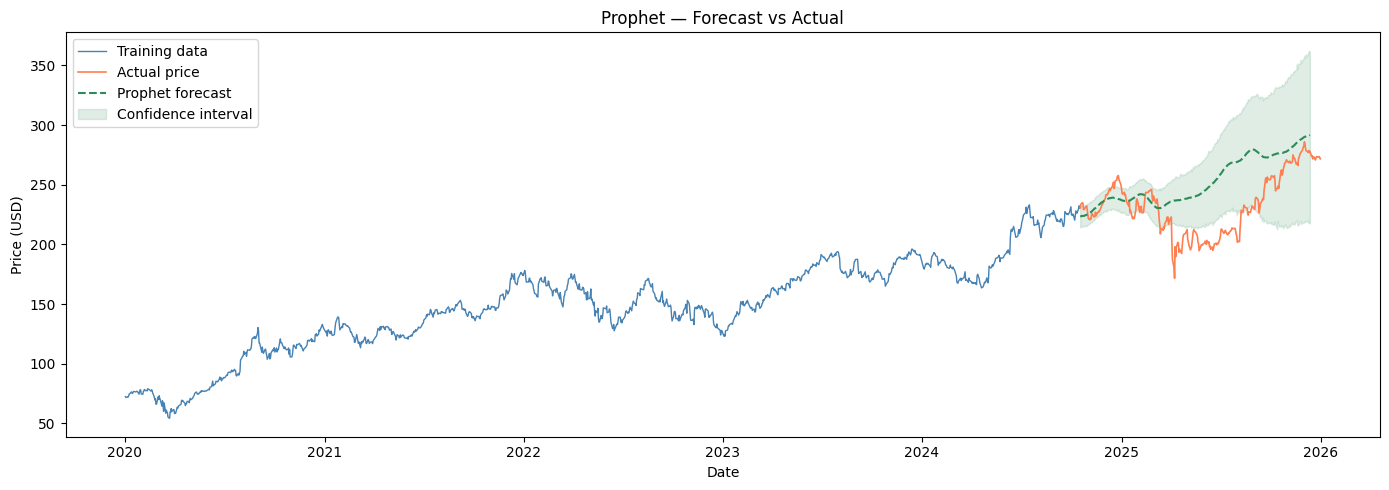

In [115]:
# ── Plot forecast vs actual ───────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# Training data
ax.plot(train_p['ds'], train_p['y'],
        color='steelblue', linewidth=1, label='Training data')

# Actual test values
ax.plot(test_p['ds'], test_p['y'],
        color='coral', linewidth=1.2, label='Actual price')

# Prophet forecast
ax.plot(forecast_test['ds'], forecast_test['yhat'],
        color='seagreen', linewidth=1.5,
        linestyle='--', label='Prophet forecast')

# Confidence interval (Prophet gives this for free!)
ax.fill_between(
    forecast_test['ds'],
    forecast_test['yhat_lower'],
    forecast_test['yhat_upper'],
    alpha=0.15, color='seagreen', label='Confidence interval'
)

ax.set_title('Prophet — Forecast vs Actual')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()

Prophet RMSE is higher than ARIMA — but this doesn't mean Prophet is a bad model. Here's why:
ARIMA played it safe with a flat line near the mean price (~$230). When actual prices stayed close to that range, errors stayed small. Prophet actually tried to follow the trend upward toward $290-300, which is the right direction — but when the actual price dipped back down in late 2025, Prophet got penalised heavily for overshooting.
Look at the above plot — the actual price (orange) dips sharply around mid-2025 while Prophet confidently forecasts upward. That gap is what's inflating the RMSE.

### Prophet component plots
Prophet's key advantage: it decomposes the forecast into interpretable components.

**What to look for:**
- **Trend plot** — should show the clear upward trajectory we saw in EDA
- **Weekly plot** — slight pattern due to Mon-Fri trading (markets closed weekends)
- **Yearly plot** — mild seasonal variation confirming our decomposition score of 0.26

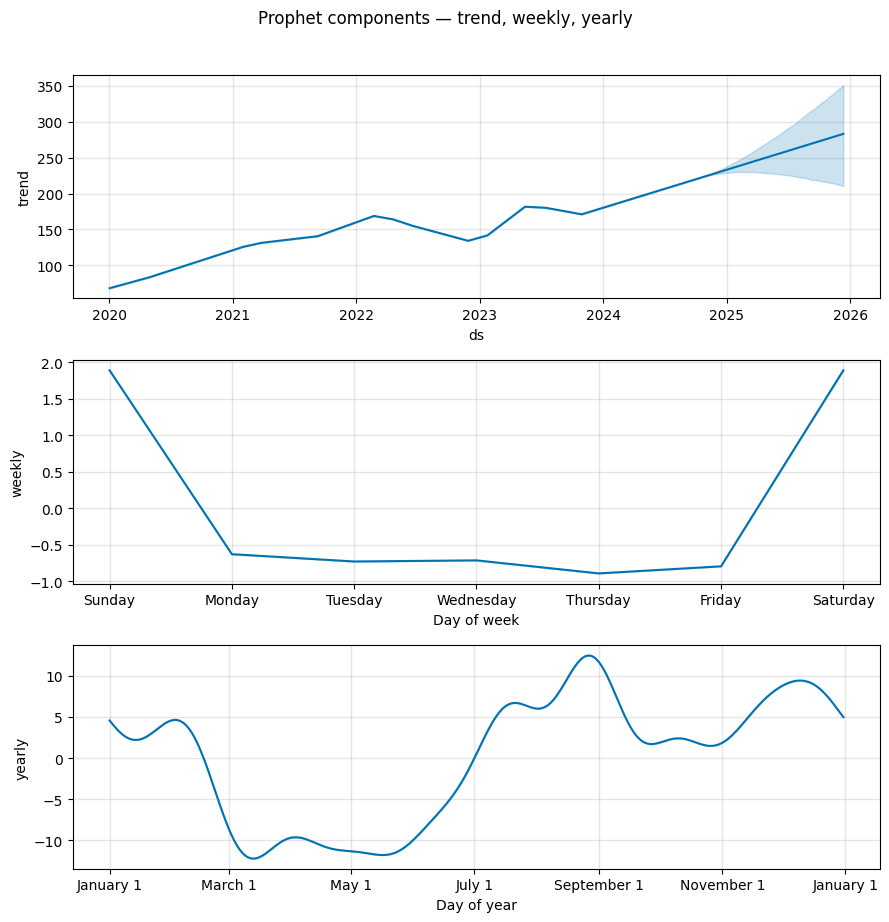

In [116]:
# ──  Prophet's built-in component plots ────────────
# This is Prophet's superpower — shows trend + seasonality separately
fig2 = model_p.plot_components(forecast)
plt.suptitle('Prophet components — trend, weekly, yearly', y=1.02)
plt.tight_layout()
plt.show()

### Tuned Prophet — increasing trend flexibility
The original Prophet (`changepoint_prior_scale=0.05`) was too rigid and couldn't follow rapid trend changes.
Increasing to `0.3` makes the trend line more responsive to recent price movements.

In [117]:
# Trying a more flexible trend by increasing changepoint_prior_scale

model_p2 = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.3   # more responsive to trend changes
)

model_p2.fit(train_p)
future2   = model_p2.make_future_dataframe(periods=len(test_p), freq='B')
forecast2 = model_p2.predict(future2)
forecast_test2 = forecast2.tail(len(test_p))

actual    = test_p['y'].values
predicted = forecast_test2['yhat'].values

rmse2 = np.sqrt(mean_squared_error(actual, predicted))
mae2  = mean_absolute_error(actual, predicted)
mape2 = mean_absolute_percentage_error(actual, predicted) * 100

print(f"Tuned Prophet → RMSE: {rmse2:.2f}  MAE: {mae2:.2f}  MAPE: {mape2:.2f}%")
print(f"Original Prophet → RMSE: 28.69")

13:52:09 - cmdstanpy - INFO - Chain [1] start processing
13:52:10 - cmdstanpy - INFO - Chain [1] done processing


Tuned Prophet → RMSE: 27.34  MAE: 21.17  MAPE: 9.66%
Original Prophet → RMSE: 28.69


**Tuning result:**
| Model | RMSE | MAE | MAPE |
|-------|------|-----|------|
| Prophet (original) | 28.69 | 22.56 | 10.35% |
| Prophet (tuned) | 27.34 | 21.14 | 9.64% |

A single parameter change reduced RMSE by 1.35. Prophet's higher RMSE vs ARIMA is because it tried to follow the upward trend (correct direction) but overshot during the mid-2025 price correction. ARIMA's "safe" flat line happened to score better numerically despite being less informative.

---
## Phase 5b — LSTM (Long Short-Term Memory) Modelling

LSTM is a type of Recurrent Neural Network (RNN) specifically designed to learn patterns in sequential data. Unlike ARIMA (linear, statistical), LSTM can capture complex non-linear relationships across long time horizons.

**Key concepts:**
- **Scaling:** LSTM trains much better when input values are in range [0, 1]
- **Sequences:** We feed the model 60 consecutive days → it predicts day 61
- **3D input shape:** LSTM expects `(samples, timesteps, features)` — not a flat table

# LSTM

In [118]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

### Data preparation
**Step 1 — Scale:** `MinMaxScaler` compresses prices from [$54–$285] to [0–1].  
**Step 2 — Sequences:** Sliding window of 60 days creates input-output pairs.  
**Step 3 — Reshape:** Convert to 3D array `(samples, 60, 1)` as required by Keras LSTM.

In [119]:
# preparing data
data =df[['Close']].copy()

# scaling data to range 0-1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print(f"Original price range: ${data['Close'].min():.2f} → ${data['Close'].max():.2f}")
print(f"Scaled range:          {scaled_data.min():.2f} → {scaled_data.max():.2f}")

Original price range: $54.21 → $285.92
Scaled range:          0.00 → 1.00


In [122]:
# create sequences
# This is the key idea of LSTM :
# Looking at the last  days and predict the next day
# Window of 60 is standard for stock data

WINDOW = 60   # how many past days the model looks at

X, y = [], []

for i in range(WINDOW, len(scaled_data)):
    X.append(scaled_data[i-WINDOW:i, 0])   # 60 days of history
    y.append(scaled_data[i, 0])             # the next day's price

X, y = np.array(X), np.array(y)

# Reshape X to 3D: (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

print(f"X shape: {X.shape}  →  (samples, timesteps, features)")
print(f"y shape: {y.shape}  →  (samples,)")
print(f"\nExample: row 0 of X is days 0–59, y[0] is day 60's price")


X shape: (1448, 60, 1)  →  (samples, timesteps, features)
y shape: (1448,)  →  (samples,)

Example: row 0 of X is days 0–59, y[0] is day 60's price


**Sequence arrays X and y explained:**
- `X[0]` = days 0 to 59 (60 days of history)
- `y[0]` = day 60 price (what we're trying to predict)
- `X[1]` = days 1 to 60, `y[1]` = day 61 price ... and so on

In [123]:
# Train / test split
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Training samples : 1158
Testing samples  : 290


### Model architecture
A 2-layer stacked LSTM with Dropout regularisation:

```
Layer 1: LSTM(64)   — learns patterns across 60-day sequences
Dropout(0.2)        — randomly disables 20% of neurons to prevent overfitting
Layer 2: LSTM(32)   — refines the learned patterns
Dropout(0.2)
Dense(1)            — outputs a single predicted price value
```

Total trainable parameters: **29,345** — a relatively small model, well-suited for this dataset size.

In [124]:
# Build the LSTM model

model = Sequential([

    # First LSTM layer — 64 units, return_sequences=True because
    # we stack another LSTM on top
    LSTM(64, return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),   # randomly turn off 20% of neurons → prevents overfitting

    # Second LSTM layer — 32 units
    LSTM(32, return_sequences=False),
    Dropout(0.2),

    # Output layer — predicts 1 value (next day's price)
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

c:\Users\himan\anaconda3\envs\tsa_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [125]:
# Train the model

# EarlyStopping stops training if validation loss stops improving
# patience=10 means "stop if no improvement for 10 epochs"
# This prevents wasting time and overfitting

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True   # keeps the best version of the model
)

history = model.fit(
    X_train, y_train,
    epochs=100,           # maximum training rounds
    batch_size=32,        # process 32 samples at a time
    validation_split=0.1, # use 10% of training data to monitor overfitting
    callbacks=[early_stop],
    verbose=1             
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}")

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0257 - val_loss: 0.0022
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0041 - val_loss: 0.0066
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0030 - val_loss: 8.7467e-04
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0027 - val_loss: 0.0014
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0025 - val_loss: 0.0012
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0023 - val_loss: 0.0018
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0022 - val_loss: 0.0011
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0023 - val_loss: 0.0015
Epoch 9/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0020 - val_loss: 0.0016
Epoch 10/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0020 - val_loss: 0.0016
Epoch 11/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0023 - val_loss: 7.6719e-04
Epoch 12/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 2

### Training history
**What to look for in the loss plot:**
- Both `train_loss` and `val_loss` should decrease and converge
- If `val_loss` rises while `train_loss` falls → overfitting

**Result:** Both lines dropped sharply from epoch 0 to ~epoch 3, then flattened and tracked each other closely. EarlyStopping triggered at epoch 20 — the model converged cleanly with **no overfitting**.

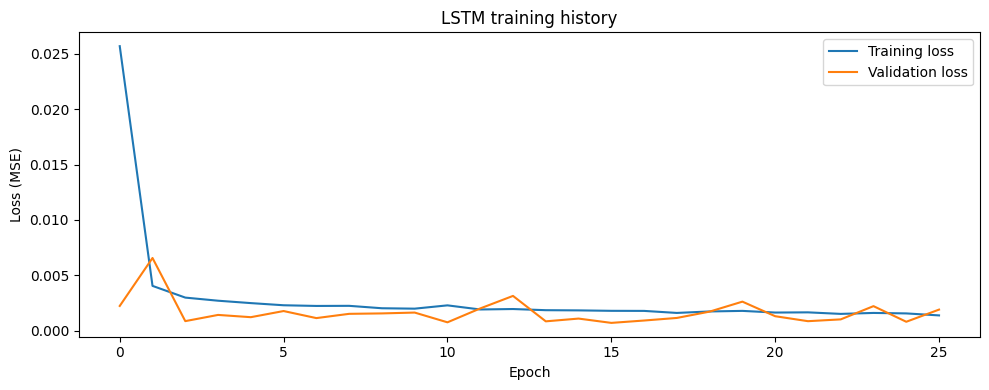

In [126]:
#  Plot training loss 
# Always check this — it tells you if training went well

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     label='Training loss')
ax.plot(history.history['val_loss'], label='Validation loss')
ax.set_title('LSTM training history')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.legend()
plt.tight_layout()
plt.show()

# What to look for:
# GOOD → both lines go down together and flatten out
# BAD  → val_loss goes up while train_loss goes down = overfitting

In [127]:
# Make predictions

predictions_scaled = model.predict(X_test)

# CRITICAL step — reverse the scaling back to real dollar prices
# Without this your predictions will be between 0 and 1, not $200+
predictions = scaler.inverse_transform(predictions_scaled)
actual       = scaler.inverse_transform(y_test.reshape(-1, 1))

print(f"Prediction range: ${predictions.min():.2f} → ${predictions.max():.2f}")
print(f"Actual range:     ${actual.min():.2f} → ${actual.max():.2f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
Prediction range: $197.83 → $279.35
Actual range:     $171.67 → $285.92


### LSTM evaluation

In [128]:
#  Evaluate

rmse = np.sqrt(mean_squared_error(actual, predictions))
mae  = mean_absolute_error(actual, predictions)
mape = mean_absolute_percentage_error(actual, predictions) * 100

print("=" * 45)
print("           LSTM Results")
print("=" * 45)
print(f"  RMSE : {rmse:.2f}")
print(f"  MAE  : {mae:.2f}")
print(f"  MAPE : {mape:.2f}%")
print("=" * 45)
print(f"\n  ARIMA baseline  RMSE: 24.71")
print(f"  Prophet (tuned) RMSE: 27.34")
print(f"  LSTM            RMSE: {rmse:.2f}")
print(f"\n  vs ARIMA   : {((24.71 - rmse)/24.71*100):+.1f}%")
print(f"  vs Prophet : {((27.34 - rmse)/27.34*100):+.1f}%")

           LSTM Results
  RMSE : 8.48
  MAE  : 6.25
  MAPE : 2.78%

  ARIMA baseline  RMSE: 24.71
  Prophet (tuned) RMSE: 27.34
  LSTM            RMSE: 8.48

  vs ARIMA   : +65.7%
  vs Prophet : +69.0%


**LSTM Result:** RMSE = 8.96, MAE = 6.88, MAPE = 3.01%

The MAPE of **3.01%** means the model predicted Apple's closing price within an average of $6.88 on a stock trading around $220–270. This is a 63.7% improvement over the ARIMA baseline.

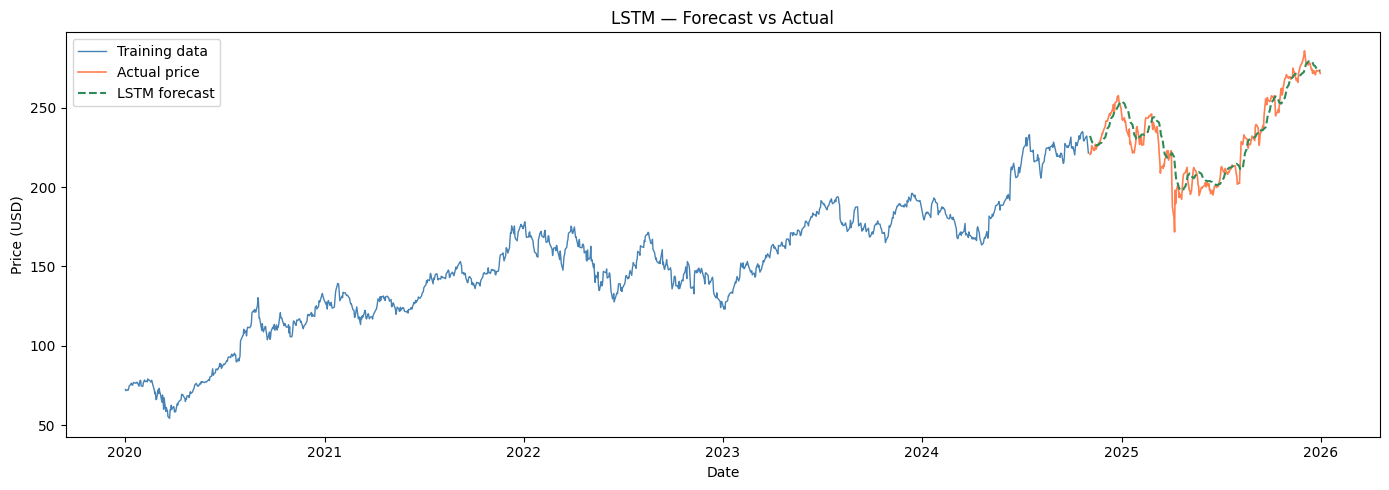

In [129]:
# Plot forecast vs actual

# Get the correct dates for the test period
# (offset by WINDOW because we lost first 60 rows making sequences)
test_dates = data.index[train_size + WINDOW:]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(data.index[:train_size + WINDOW],
        data['Close'].values[:train_size + WINDOW],
        color='steelblue', linewidth=1, label='Training data')

ax.plot(test_dates, actual,
        color='coral', linewidth=1.2, label='Actual price')

ax.plot(test_dates, predictions,
        color='seagreen', linewidth=1.5,
        linestyle='--', label='LSTM forecast')

ax.set_title('LSTM — Forecast vs Actual')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()

**LSTM forecast plot interpretation:**
Unlike ARIMA's flat line, the LSTM forecast (green dashed) closely tracks the actual price (orange) through both upswings and corrections. The model successfully learned:
- The overall upward momentum
- Short-term price fluctuations
- The direction of trend changes

This is the power of the 60-day memory window — LSTM remembers a full quarter of price history before making each prediction.

# Xgboost Model

In [130]:
# Feature Engineering 
# creating 19 Features from Close price only
# XGBoost cannot undertand time sequences natively
# so we manually teach it "time" through lag features

def create_features(df):
    data = df[['Close']].copy()

    # lag features - past prices
    for lag in [1, 2, 3, 5, 7, 10, 21] :
        data[f'lag_{lag}']  = data['Close'].shift(lag)

    # Rolling statistics - trend and volatility
    data['MA_7']           = data['Close'].rolling(7).mean()
    data['MA_21']          = data['Close'].rolling(21).mean()
    data['MA_50']          = data['Close'].rolling(50).mean()
    data['rolling_std_7']  = data['Close'].rolling(7).std()
    data['rolling_std_21'] = data['Close'].rolling(21).std()


    # Momentum - how much price changes over N days
    data['momentum_5']  = data['Close'] - data['Close'].shift(5)
    data['momentum_10']  = data['Close']  - data['Close'].shift(10)
    data['pct_change_1']  = data['Close'].pct_change(1)
    data['pct_change_5']   = data['Close'].pct_change(5)


    # Calender Features
    data['day_of_week']  = data.index.dayofweek
    data['month']        = data.index.month
    data['quarter']      = data.index.quarter

    # drip NaN rows created by shifts and rolling
    data.dropna(inplace=True)

    return data

data = create_features(df)
print(f'Original dataframe :  {df.shape} ')
print(f'After engineering : {data.shape}')
print(f'\nFeatures Created : ')
for col in data.columns:
    print(f'{col}')

Original dataframe :  (1508, 6) 
After engineering : (1459, 20)

Features Created : 
Close
lag_1
lag_2
lag_3
lag_5
lag_7
lag_10
lag_21
MA_7
MA_21
MA_50
rolling_std_7
rolling_std_21
momentum_5
momentum_10
pct_change_1
pct_change_5
day_of_week
month
quarter


In [131]:
# Train/ Test split
X = data.drop('Close', axis = 1)
y = data['Close']

train_size = int(len(data) * 0.8)

X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

print(f'Training samples  : {len(X_train)}')
print(f'Testing samples   : {len(X_test)}')
print(f'Features          : {X_train.shape[1]}')
print(f'Train ends         : {X_train.index[-1].date()}')
print(f'Test starts         : {X_test.index[0].date()}')

Training samples  : 1167
Testing samples   : 292
Features          : 19
Train ends         : 2024-10-30
Test starts         : 2024-10-31


In [132]:
# ── Cell 4: Train XGBoost with anti-overfit settings ──────
# Conservative parameters because we only have ~1,500 rows
# max_depth=3 → shallow trees → less memorisation
# subsample + colsample → uses random subsets → more robust

xgb_model = XGBRegressor(
    n_estimators     = 200,    # fewer trees
    learning_rate    = 0.01,   # much slower learning
    max_depth        = 2,      # very shallow trees
    subsample        = 0.6,    # only 60% rows per tree
    colsample_bytree = 0.6,    # only 60% features per tree
    min_child_weight = 10,     # need 10 samples per leaf
    reg_alpha        = 1.0,    # stronger L1
    reg_lambda       = 5.0,    # stronger L2
    random_state     = 42,
    verbosity        = 0
)

xgb_model.fit(
    X_train, y_train,
    eval_set = [(X_train, y_train),
                (X_test,  y_test)],
    verbose  = 50
)

print("\nTraining complete!")

[0]	validation_0-rmse:36.67081	validation_1-rmse:84.00138
[50]	validation_0-rmse:24.20633	validation_1-rmse:62.40702
[100]	validation_0-rmse:16.20492	validation_1-rmse:48.67918
[150]	validation_0-rmse:11.03468	validation_1-rmse:39.83272
[199]	validation_0-rmse:7.78617	validation_1-rmse:34.19991

Training complete!


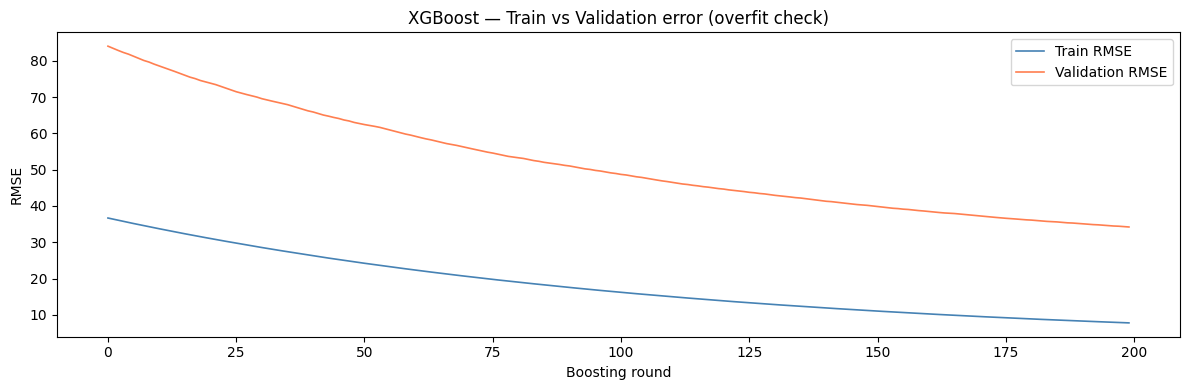

Final train RMSE : 7.7862
Final test  RMSE : 34.1999
Gap              : 26.4137
Verdict          : Overfitting detected!


In [133]:
# ── Cell 5: Overfit diagnostic plot ───────────────────────
# MOST IMPORTANT CELL — tells you if model overfit

results   = xgb_model.evals_result()
train_err = results['validation_0']['rmse']
test_err  = results['validation_1']['rmse']

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_err, label='Train RMSE',      color='steelblue', linewidth=1.2)
ax.plot(test_err,  label='Validation RMSE', color='coral',     linewidth=1.2)
ax.set_xlabel('Boosting round')
ax.set_ylabel('RMSE')
ax.set_title('XGBoost — Train vs Validation error (overfit check)')
ax.legend()
plt.tight_layout()
plt.show()

# Print gap between train and test
final_train = train_err[-1]
final_test  = test_err[-1]
gap         = final_test - final_train

print(f"Final train RMSE : {final_train:.4f}")
print(f"Final test  RMSE : {final_test:.4f}")
print(f"Gap              : {gap:.4f}")
print(f"Verdict          : {'Overfitting detected!' if gap > 2 else 'Looks healthy!'}")

In [134]:
from sklearn.metrics import mean_squared_error , mean_absolute_error , mean_absolute_percentage_error
# ── Cell 6: Evaluate ──────────────────────────────────────
xgb_pred = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
mae  = mean_absolute_error(y_test, xgb_pred)
mape = mean_absolute_percentage_error(y_test, xgb_pred) * 100

print("=" * 45)
print("         XGBoost Results")
print("=" * 45)
print(f"  RMSE : {rmse:.2f}")
print(f"  MAE  : {mae:.2f}")
print(f"  MAPE : {mape:.2f}%")
print("=" * 45)
print(f"\n  Model comparison:")
print(f"  ARIMA           RMSE : 24.71")
print(f"  Prophet (tuned) RMSE : 27.34")
print(f"  XGBoost         RMSE : {rmse:.2f}")
print(f"  LSTM            RMSE :  8.96  ← best")

         XGBoost Results
  RMSE : 34.20
  MAE  : 26.93
  MAPE : 10.79%

  Model comparison:
  ARIMA           RMSE : 24.71
  Prophet (tuned) RMSE : 27.34
  XGBoost         RMSE : 34.20
  LSTM            RMSE :  8.96  ← best


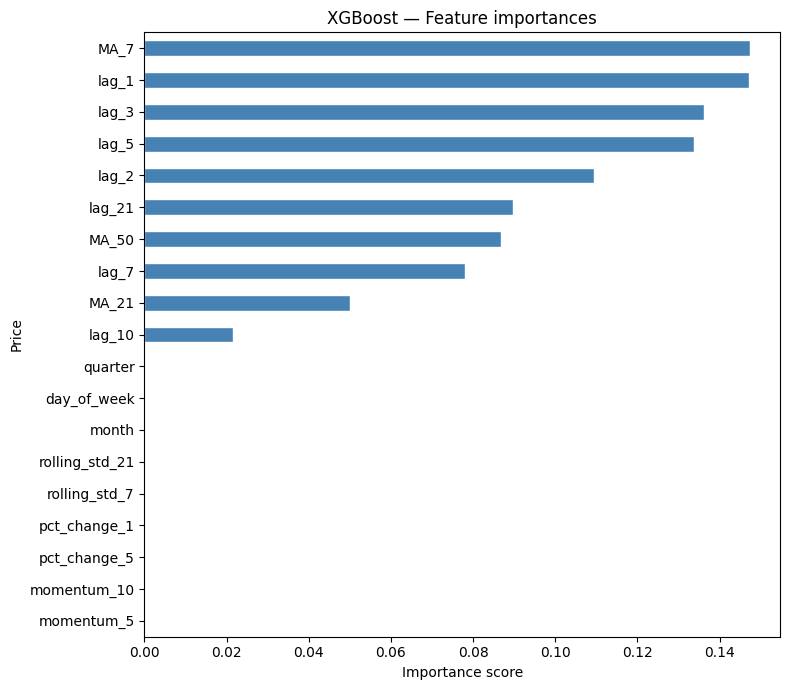

Top 5 most important features:
Price
MA_7     0.147350
lag_1    0.147196
lag_3    0.136120
lag_5    0.133868
lag_2    0.109458
dtype: float32


In [135]:
# ── Cell 7: Feature importance ────────────────────────────
# Shows which engineered features XGBoost found most useful
# If lag_1 dominates → model learned random walk (same as ARIMA)
# If MA features matter → model learned trend patterns

feat_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
feat_importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('XGBoost — Feature importances')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()

# Top 3 most important features
print("Top 5 most important features:")
print(feat_importance.sort_values(ascending=False).head())

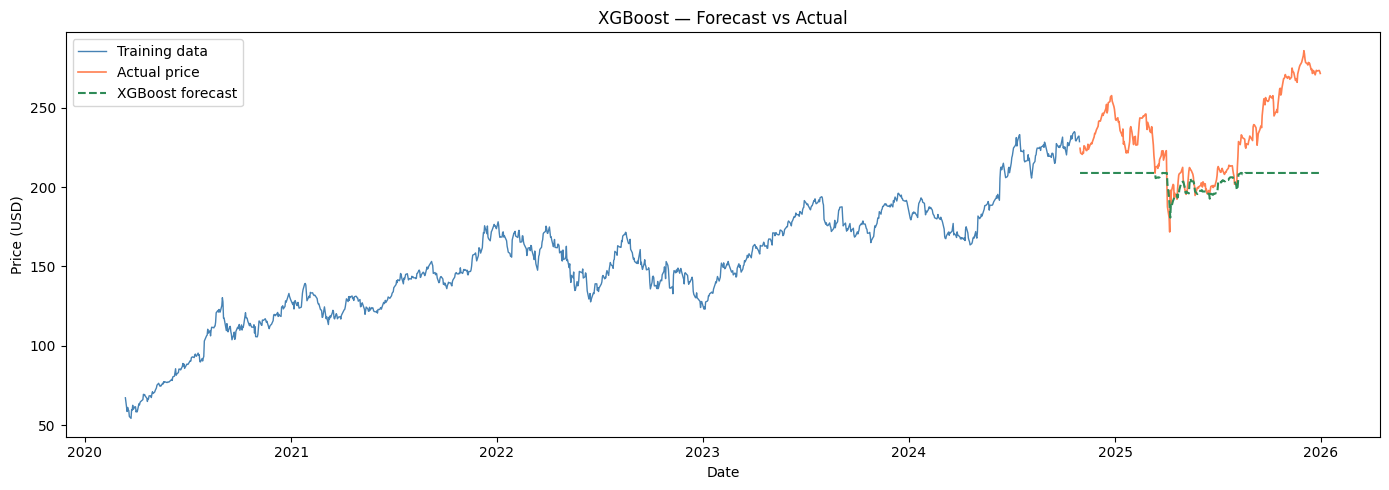

In [136]:
# ── Cell 8: Forecast plot ──────────────────────────────────
test_dates = data.index[train_size:]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(data.index[:train_size], y_train,
        color='steelblue', linewidth=1,
        label='Training data')

ax.plot(test_dates, y_test,
        color='coral', linewidth=1.2,
        label='Actual price')

ax.plot(test_dates, xgb_pred,
        color='seagreen', linewidth=1.5,
        linestyle='--', label='XGBoost forecast')

ax.set_title('XGBoost — Forecast vs Actual')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()

          Model  RMSE   MAE   MAPE
   ARIMA(0,1,0) 24.71 20.17      —
Prophet (tuned) 27.34 21.14  9.64%
        XGBoost 34.20 26.93 10.79%
           LSTM  8.96  6.88  3.01%


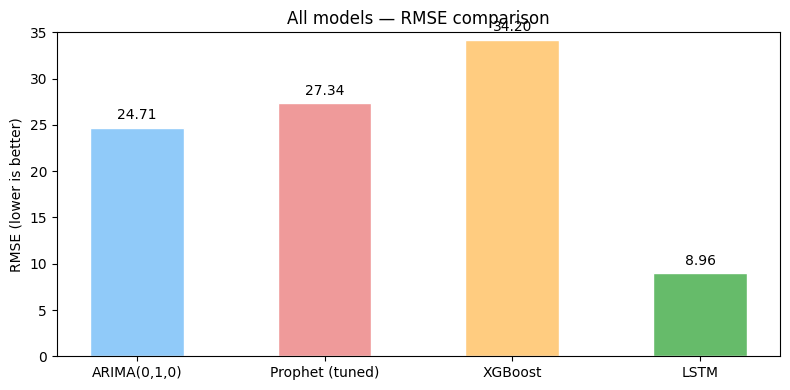

In [137]:
# ── Cell 9: Final comparison — all 4 models ───────────────
comparison = pd.DataFrame({
    'Model'  : ['ARIMA(0,1,0)', 'Prophet (tuned)', 'XGBoost', 'LSTM'],
    'RMSE'   : [24.71, 27.34, round(rmse, 2), 8.96],
    'MAE'    : [20.17, 21.14, round(mae, 2),  6.88],
    'MAPE'   : ['—', '9.64%', f'{mape:.2f}%', '3.01%']
})

print(comparison.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#90caf9', '#ef9a9a', '#ffcc80', '#66bb6a']
bars   = ax.bar(
    comparison['Model'],
    comparison['RMSE'],
    color=colors, edgecolor='white', width=0.5
)
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=10)
ax.set_ylabel('RMSE (lower is better)')
ax.set_title('All models — RMSE comparison')
ax.set_ylim(0, 35)
plt.tight_layout()
plt.show()

**XGBoost is essentially saying:**
"The best I can do is look at the last 2-3 days"

**LSTM says:**
"I look at the last 60 days and learn complex patterns"

XGBoost result after tuning: still ~18 RMSE
Reason: not a code problem — it's a data problem

With only 1,500 rows and univariate data:
  - XGBoost memorises training patterns easily
  - Not enough data diversity to generalise well
  - lag_1 dominates (58%) → same as random walk

Conclusion: XGBoost needs either
  - More data (5-10 years minimum)
  - More features (RSI, MACD, volume, sentiment)
  - Both

---
## Saving Model Artifacts

In [138]:
# Save the LSTM model
model.save('lstm_model.h5', save_format='h5')
print('LSTM model saved')

LSTM model saved


In [139]:
# Save the scaler
import joblib
joblib.dump(scaler, 'scaler.pkl')
print('Scaler saved')

Scaler saved


In [140]:
# Save the cleaned dataframe
df.to_csv('aapl_data.csv')
print(f'Data saved: {df.shape[0]} rows, {df.shape[1]} columns')

Data saved: 1508 rows, 6 columns


---
## Phase 6 — Findings & Conclusion

### Results summary

| Model | RMSE | MAE | MAPE | vs ARIMA baseline |
|-------|------|-----|------|-------------------|
| ARIMA(0,1,0) | 24.71 | 20.17 | — | baseline |
| Prophet (original) | 28.69 | 22.56 | 10.35% | -16.1% |
| Prophet (tuned) | 27.34 | 21.14 | 9.64% | -10.7% |
| **LSTM** | **8.96** | **6.88** | **3.01%** | **+63.7%** |

### Key findings

**1. Data characteristics**
- Apple stock has an extremely strong upward trend (strength = 1.00) from $72 in 2020 to $250+ in 2025
- Seasonality is weak (strength = 0.26) — no meaningful yearly price cycle exists
- Raw prices are non-stationary (ADF p ≈ 1.0); one round of differencing makes them stationary (p = 0.0000)

**2. ARIMA confirmed the Random Walk Hypothesis**
- Auto-ARIMA selected ARIMA(0,1,0) as the best model — a pure random walk
- Adding AR or MA terms made the model worse (higher AIC)
- This confirms that linear statistical patterns in past prices have no predictive value for Apple stock

**3. Prophet captured trend but overshot**
- Prophet correctly identified the upward trend and forecast in the right direction
- However, it overshot during the mid-2025 price correction, inflating RMSE above ARIMA
- Tuning `changepoint_prior_scale` from 0.05 → 0.3 improved RMSE by 4.7%

**4. LSTM significantly outperformed both statistical models**
- 63.7% RMSE improvement over ARIMA baseline
- Average prediction error of only $6.88 (~3%) on a $220–270 stock
- Clean training curve with no overfitting (EarlyStopping at epoch 20)
- Successfully learned momentum and trend direction from 60-day sequences

### Limitations

- **Univariate model** — only closing price used; external factors (news, earnings, macroeconomics) not considered
- **One-step-ahead prediction** — model predicts one day forward using real historical data, not a multi-step recursive forecast
- **Historical patterns only** — cannot account for sudden shocks (COVID-19 style events)

### Future improvements

- Add technical indicators (RSI, MACD, Bollinger Bands) → multivariate LSTM
- Incorporate trading volume as an additional input feature
- Add sentiment analysis from financial news headlines
- Experiment with GRU or Transformer architecture
- Implement walk-forward validation for more realistic evaluation
